In [31]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt

files = {
    "bg0":   Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 0 bg/7.9 0 bg_MMStack_Pos0.ome.tif"),
    "bg45":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 45 bg/7.9 45 bg_MMStack_Pos0.ome.tif"),
    "bg90":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 90 bg/7.9 90 bg_MMStack_Pos0.ome.tif"),
    "bg135":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 135 bg/7.9 135 bg_MMStack_Pos0.ome.tif"),

    "sample0":   Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 0 sample30/7.9 0 sample30_MMStack_Pos0.ome.tif"),
    "sample45":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 45 sample30/7.9 45 sample30_MMStack_Pos0.ome.tif"),
    "sample90":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 90 sample30/7.9 90 sample30_MMStack_Pos0.ome.tif"),
    "sample135": Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 135 sample30/7.9 135 sample30_MMStack_Pos0.ome.tif"),
}

for key, path in files.items():
    print(f"{key}: exists={path.exists()} -> {path}")

bg0: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 0 bg/7.9 0 bg_MMStack_Pos0.ome.tif
bg45: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 45 bg/7.9 45 bg_MMStack_Pos0.ome.tif
bg90: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 90 bg/7.9 90 bg_MMStack_Pos0.ome.tif
bg135: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 135 bg/7.9 135 bg_MMStack_Pos0.ome.tif
sample0: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 0 sample30/7.9 0 sample30_MMStack_Pos0.ome.tif
sample45: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 45 sample30/7.9 45 sample30_MMStack_Pos0.ome.tif
sample90: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 90 sample30/7.9 90 sample30_MMStack_Pos0.ome.tif
sample135: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.9 data/7.9 135 sample30/7.9 135 sample30_MMStack_Pos0.ome.tif


In [32]:
def load_ome_tif(path):
    """
    Read OME-TIFF and return one 2D float64 image.
    If multiple frames exist, use the first frame after squeeze.
    """
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    arr = tifffile.imread(path)
    arr = np.squeeze(arr)

    print(f"{path.name}: shape={arr.shape}, dtype={arr.dtype}")

    if arr.ndim == 2:
        img = arr
    elif arr.ndim == 3:
        print(f"Warning: using first frame arr[0] from shape {arr.shape}")
        img = arr[0]
    else:
        raise ValueError(f"Unsupported image shape: {arr.shape}")

    return img.astype(np.float64)

In [33]:
def split_pol_channels(raw):
    """
    Split raw mosaic using pattern:
        [ I0,  I135  ]
        [ I45,   I90 ]
    """
    if raw.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {raw.shape}")

    I0  = raw[0::2, 0::2]
    I135  = raw[0::2, 1::2]
    I45   = raw[1::2, 0::2]
    I90 = raw[1::2, 1::2]

    return I0, I45, I90, I135

In [34]:
def stokes_from_raw(raw, eps=1e-12):
    """
    Compute Stokes maps from one raw image.
    Main quantities used later are normalized s1 and s2.
    """
    I0, I45, I90, I135 = split_pol_channels(raw)

    S0 = 0.5 * (I0 + I45 + I90 + I135)
    S1 = I0 - I90
    S2 = I45 - I135

    s1 = S1 / (S0 + eps)
    s2 = S2 / (S0 + eps)

    return {
        "I0": I0,
        "I45": I45,
        "I90": I90,
        "I135": I135,
        "S0": S0,
        "S1": S1,
        "S2": S2,
        "s1": s1,
        "s2": s2,
    }

In [35]:
raw_data = {}
stokes = {}

for key, path in files.items():
    print(f"\nLoading: {key}")
    raw_img = load_ome_tif(path)
    raw_data[key] = raw_img
    stokes[key] = stokes_from_raw(raw_img)

    print(f"{key}: s1/s2 shape = {stokes[key]['s1'].shape}")


Loading: bg0
7.9 0 bg_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
bg0: s1/s2 shape = (1024, 1216)

Loading: bg45
7.9 45 bg_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
bg45: s1/s2 shape = (1024, 1216)

Loading: bg90
7.9 90 bg_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
bg90: s1/s2 shape = (1024, 1216)

Loading: bg135
7.9 135 bg_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
bg135: s1/s2 shape = (1024, 1216)

Loading: sample0
7.9 0 sample30_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
sample0: s1/s2 shape = (1024, 1216)

Loading: sample45
7.9 45 sample30_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
sample45: s1/s2 shape = (1024, 1216)

Loading: sample90
7.9 90 sample30_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
sample90: s1/s2 shape = (1024, 1216)

Loading: sample135
7.9 135 sample30_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
sample135: s1/s2 shape = (1024, 1216)


In [36]:
example_key = "bg0"

print(f"Example: {example_key}")

print("\ns1 first 5x5:")
print(stokes[example_key]["s1"][:5, :5])

print("\ns2 first 5x5:")
print(stokes[example_key]["s2"][:5, :5])

Example: bg0

s1 first 5x5:
[[0.94879518 0.96396396 0.95037594 0.94720965 0.9183359 ]
 [0.9439528  0.97451274 0.97420334 0.95022624 0.9347181 ]
 [0.97313433 0.91933029 0.93939394 0.95324284 0.95820896]
 [0.93273543 0.9648855  0.96352584 0.9648855  0.97014925]
 [0.94578313 0.96229261 0.96072508 0.95238095 0.96755162]]

s2 first 5x5:
[[-0.01506024 -0.03903904 -0.05714286 -0.00904977 -0.00924499]
 [-0.02359882 -0.02998501 -0.01213961 -0.03016591 -0.03264095]
 [-0.08358209 -0.02130898 -0.03636364 -0.02714932 -0.03283582]
 [-0.01494768 -0.02748092 -0.02735562 -0.01526718 -0.00298507]
 [-0.01807229 -0.03016591 -0.03021148 -0.00921659 -0.00589971]]


In [37]:
# === Cell 1: Build measured input/output Stokes cubes ===

in_keys = ["bg0", "bg45", "bg90", "bg135"]
out_keys = ["sample0", "sample45", "sample90", "sample135"]

shape0 = stokes[in_keys[0]]["S0"].shape

for key in in_keys + out_keys:
    if stokes[key]["S0"].shape != shape0:
        raise ValueError(f"Shape mismatch in {key}: {stokes[key]['S0'].shape} vs {shape0}")

H, W = shape0
print("Polarization sub-image shape:", (H, W))

# X_meas: measured input Stokes, shape (3, 4, H, W)
# Y_meas: measured output Stokes, shape (3, 4, H, W)
X_meas = np.zeros((3, 4, H, W), dtype=np.float64)
Y_meas = np.zeros((3, 4, H, W), dtype=np.float64)

for j, key in enumerate(in_keys):
    X_meas[0, j] = stokes[key]["S0"]
    X_meas[1, j] = stokes[key]["S1"]
    X_meas[2, j] = stokes[key]["S2"]

for j, key in enumerate(out_keys):
    Y_meas[0, j] = stokes[key]["S0"]
    Y_meas[1, j] = stokes[key]["S1"]
    Y_meas[2, j] = stokes[key]["S2"]

print("X_meas shape:", X_meas.shape)
print("Y_meas shape:", Y_meas.shape)

Polarization sub-image shape: (1024, 1216)
X_meas shape: (3, 4, 1024, 1216)
Y_meas shape: (3, 4, 1024, 1216)


In [38]:
# === Cell 2: Compute pixel-wise 3x3 reduced Mueller matrix using Moore-Penrose pseudo-inverse ===

# Rearrange so that each pixel holds one matrix:
# X_hw: (H, W, 3, 4)
# Y_hw: (H, W, 3, 4)
X_hw = np.moveaxis(X_meas, [0, 1], [-2, -1])
Y_hw = np.moveaxis(Y_meas, [0, 1], [-2, -1])

# Moore-Penrose pseudo-inverse for each pixel
# X_pinv_hw: (H, W, 4, 3)
# rcond can be tuned; 1e-6 is a reasonable starting point for noisy experimental data
X_pinv_hw = np.linalg.pinv(X_hw, rcond=1e-6)

# Solve M = Y @ X^+
# (H,W,3,4) @ (H,W,4,3) -> (H,W,3,3)
M_hw = Y_hw @ X_pinv_hw

# Convert back to (3, 3, H, W) for easier plotting/saving
M = np.moveaxis(M_hw, [-2, -1], [0, 1])

print("Reduced Mueller matrix shape:", M.shape)

Reduced Mueller matrix shape: (3, 3, 1024, 1216)


Condition number statistics of X:
min    = 1.4281653149524887
max    = 1.6899475949809255
mean   = 1.486360659507515
median = 1.4857190554685982


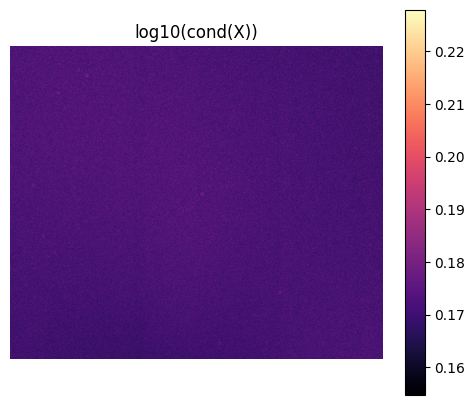

In [39]:
# === Cell 3: Diagnose conditioning of measured input matrix X ===

cond_map = np.linalg.cond(X_hw)

print("Condition number statistics of X:")
print("min    =", np.nanmin(cond_map))
print("max    =", np.nanmax(cond_map))
print("mean   =", np.nanmean(cond_map))
print("median =", np.nanmedian(cond_map))

plt.figure(figsize=(6, 5))
im = plt.imshow(np.log10(cond_map), cmap="magma")
plt.title("log10(cond(X))")
plt.axis("off")
plt.colorbar(im)
plt.show()

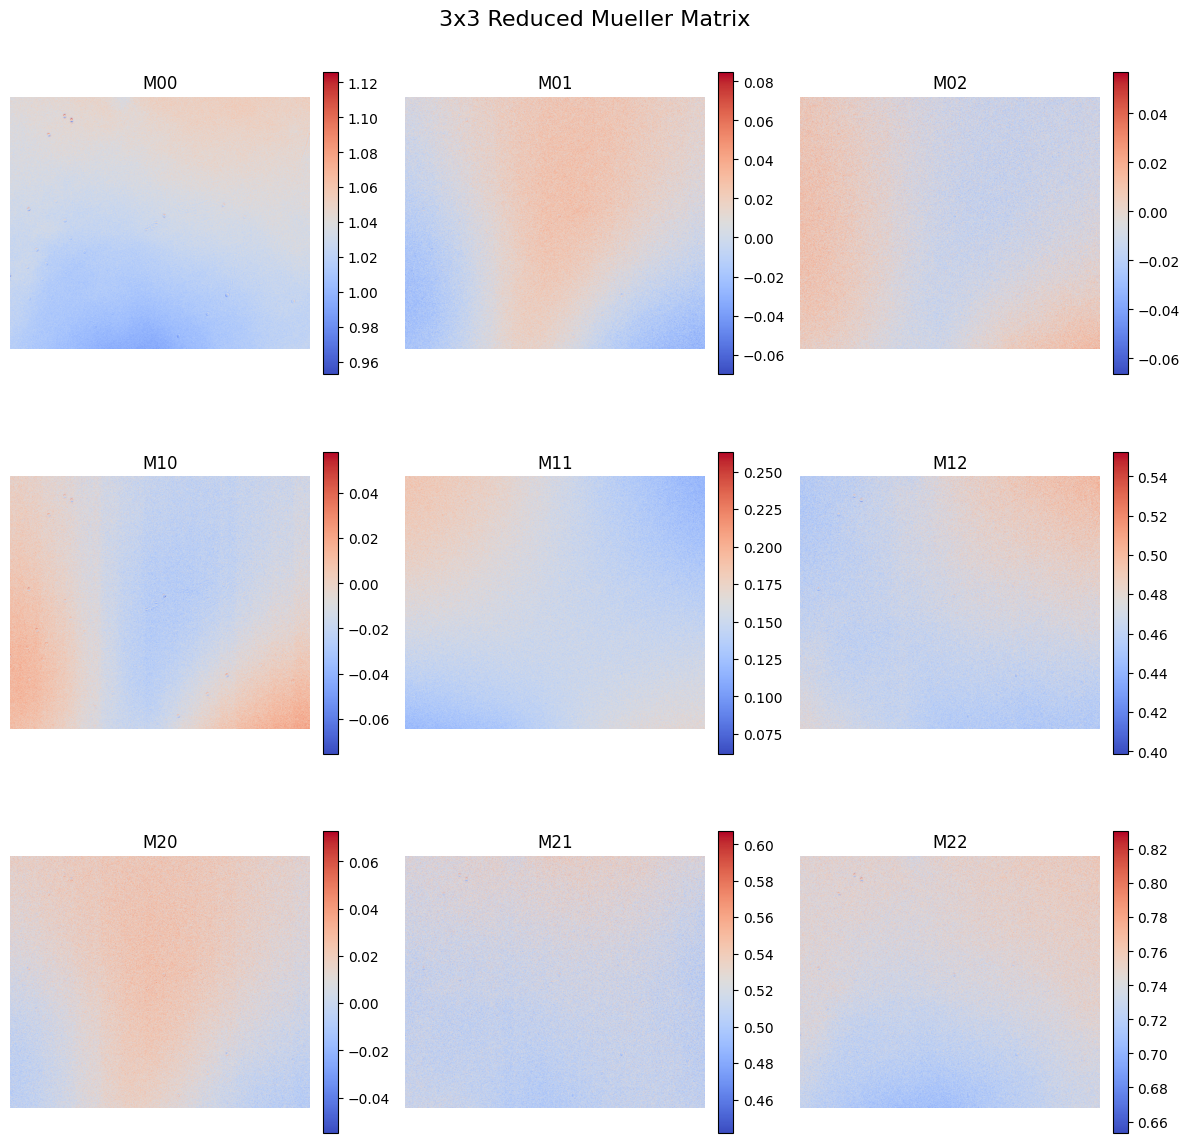

In [40]:
# === Cell 4: Visualize the 3x3 reduced Mueller matrix ===

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("3x3 Reduced Mueller Matrix", fontsize=16)

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        img = M[i, j]
        im = ax.imshow(img, cmap="coolwarm")
        ax.set_title(f"M{i}{j}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

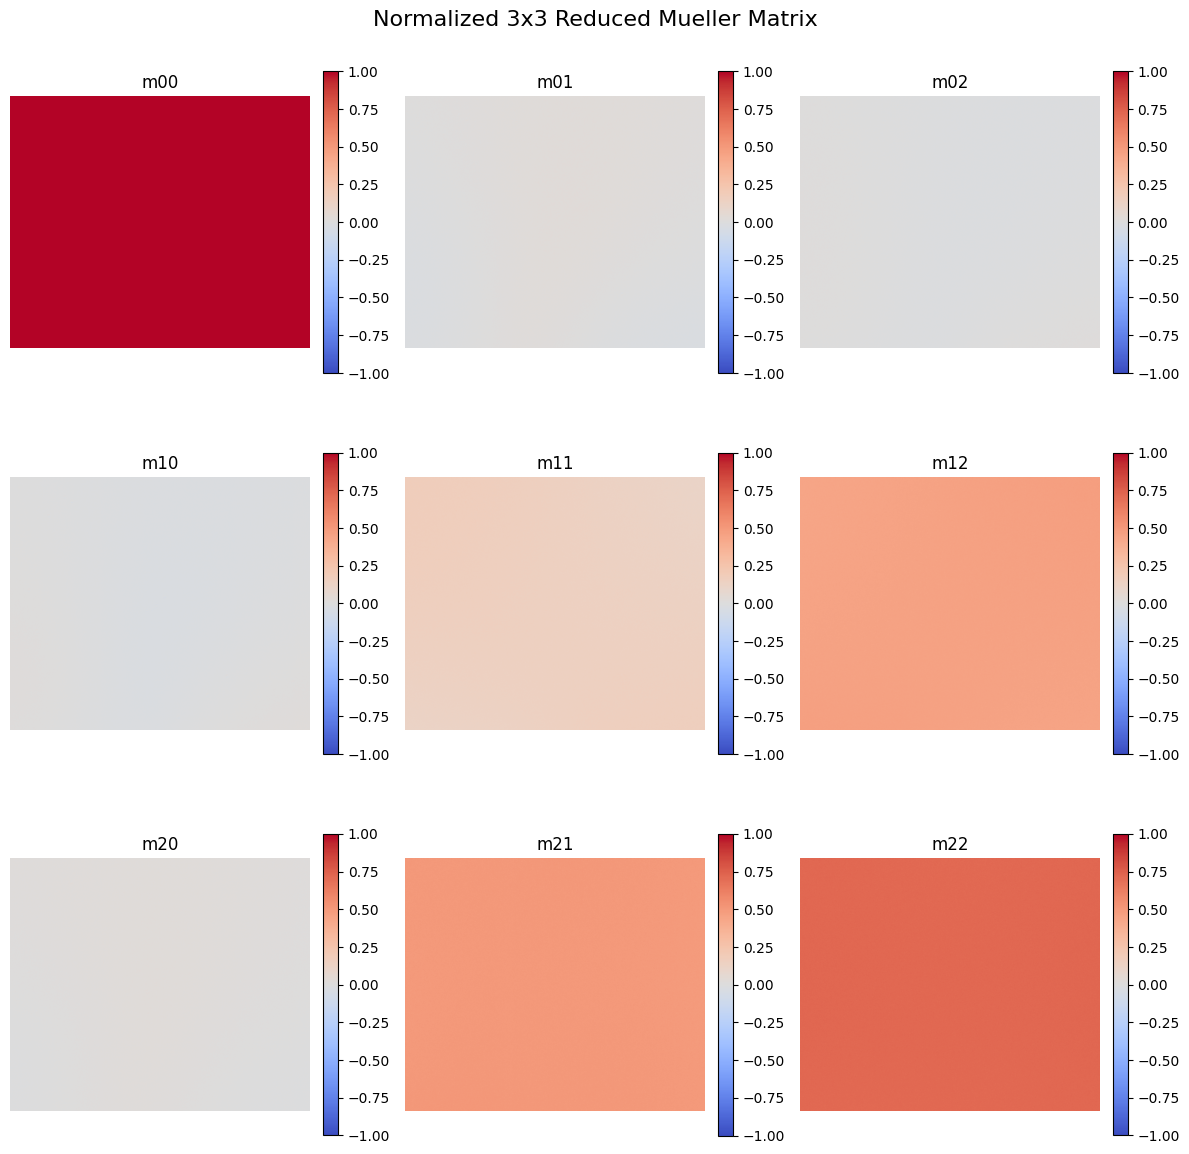

In [41]:
# === Cell 5: Normalize by M00 and visualize ===

eps_norm = 1e-12
M00 = M[0, 0]
M_norm = M / (M00[None, None, :, :] + eps_norm)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Normalized 3x3 Reduced Mueller Matrix", fontsize=16)

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        img = M_norm[i, j]
        im = ax.imshow(img, cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_title(f"m{i}{j}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [42]:
# === Cell 6: Save raw 3x3 Mueller matrix as a 9-page TIFF stack for ImageJ ===

save_dir = Path("./mueller_output")
save_dir.mkdir(parents=True, exist_ok=True)

M_stack = M.reshape(9, H, W).astype(np.float32)
mueller_stack_path = save_dir / "reduced_mueller_3x3_stack.tif"

tifffile.imwrite(mueller_stack_path, M_stack, imagej=True)
print(f"Saved: {mueller_stack_path}")

print("Page order:")
for idx in range(9):
    i, j = divmod(idx, 3)
    print(f"page {idx}: M{i}{j}")

Saved: mueller_output/reduced_mueller_3x3_stack.tif
Page order:
page 0: M00
page 1: M01
page 2: M02
page 3: M10
page 4: M11
page 5: M12
page 6: M20
page 7: M21
page 8: M22


In [43]:
# === Cell 7: Save each Mueller element as an individual TIFF ===

for i in range(3):
    for j in range(3):
        out_path = save_dir / f"M{i}{j}.tif"
        tifffile.imwrite(out_path, M[i, j].astype(np.float32))
        print(f"Saved: {out_path}")

Saved: mueller_output/M00.tif
Saved: mueller_output/M01.tif
Saved: mueller_output/M02.tif
Saved: mueller_output/M10.tif
Saved: mueller_output/M11.tif
Saved: mueller_output/M12.tif
Saved: mueller_output/M20.tif
Saved: mueller_output/M21.tif
Saved: mueller_output/M22.tif


In [44]:
# === Cell 8: Save normalized Mueller matrix as TIFF ===

M_norm_stack = M_norm.reshape(9, H, W).astype(np.float32)
mueller_norm_stack_path = save_dir / "reduced_mueller_3x3_normalized_stack.tif"

tifffile.imwrite(mueller_norm_stack_path, M_norm_stack, imagej=True)
print(f"Saved: {mueller_norm_stack_path}")

for i in range(3):
    for j in range(3):
        out_path = save_dir / f"m{i}{j}_normalized.tif"
        tifffile.imwrite(out_path, M_norm[i, j].astype(np.float32))
        print(f"Saved: {out_path}")

Saved: mueller_output/reduced_mueller_3x3_normalized_stack.tif
Saved: mueller_output/m00_normalized.tif
Saved: mueller_output/m01_normalized.tif
Saved: mueller_output/m02_normalized.tif
Saved: mueller_output/m10_normalized.tif
Saved: mueller_output/m11_normalized.tif
Saved: mueller_output/m12_normalized.tif
Saved: mueller_output/m20_normalized.tif
Saved: mueller_output/m21_normalized.tif
Saved: mueller_output/m22_normalized.tif
